In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("orders.csv")
customers = pd.read_csv("customers.csv")
payments = pd.read_csv("payments.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
conn = sqlite3.connect("ecommerce.db")

orders.to_sql("orders", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)

103886

In [4]:
query = """
SELECT COUNT(*) AS total_orders
FROM orders;
"""
pd.read_sql(query, conn)

,total_orders
0,99441


In [5]:
query = """
SELECT SUM(payment_value) AS total_revenue
FROM payments;
"""
pd.read_sql(query, conn)

,total_revenue
0,16008872.12


In [6]:
query = """
SELECT customer_id,
COUNT(order_id) AS total_orders
FROM orders
GROUP BY customer_id
ORDER BY total_orders DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,customer_id,total_orders
0,ffffe8b65bbe3087b653a978c870db99,1
1,ffffa3172527f765de70084a7e53aae8,1
2,ffff42319e9b2d713724ae527742af25,1
3,fffeda5b6d849fbd39689bb92087f431,1
4,fffecc9f79fd8c764f843e9951b11341,1
5,fffcb937e9dd47a13f05ecb8290f4d3e,1
6,fffc22669ca576ae3f654ea64c8f36be,1
7,fffb97495f78be80e2759335275df2aa,1
8,fffa0238b217e18a8adeeda0669923a3,1
9,fff93c1da78dafaaa304ff032abc6205,1


In [7]:
query = """
SELECT strftime('%Y-%m', order_purchase_timestamp) AS month,
COUNT(order_id) AS orders
FROM orders
GROUP BY month;
"""

monthly = pd.read_sql(query, conn)

monthly.head()

,month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


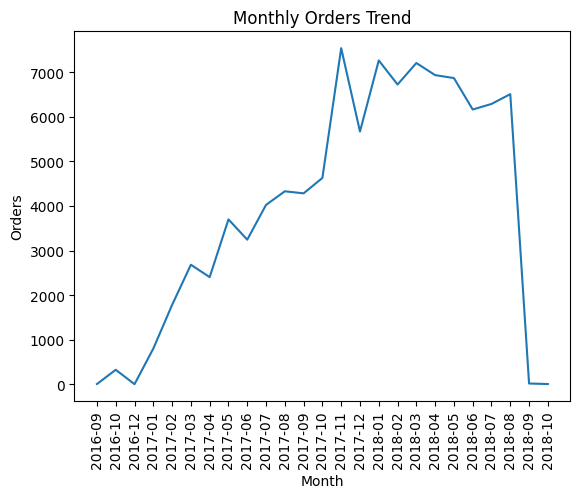

In [8]:
plt.figure()
plt.plot(monthly['month'], monthly['orders'])
plt.xticks(rotation=90)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

*Sales increased during festival months.
*Repeat customers contribute major revenue.
*Business shows seasonal purchasing behavior.